In [ ]:

import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 128
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import PathMNIST

# load the data
train_dataset = PathMNIST(split='train', size=224, root="/home/bobsun/cambrige/MedMinist/data",
                          transform=data_transform, download=True)
test_dataset = PathMNIST(split='test', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)

def test(model, test_loader):
    model.eval()
    test_total = 0
    test_correct = 0
    # Disable gradient calculation for faster inference
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            # Forward pass
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            # Update correct and total counts
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    # Calculate accuracy
    test_accuracy = 100 * test_correct / test_total
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    return test_accuracy

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz
Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz


In [2]:
from torch import nn
import torch
from MedMinist.resnet import no_inplace_resnet18
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载原始模型
original_model = torch.load('pathmnist_resnet_94.92.pth', map_location='cpu')

# 创建新的模型实例
num_classes = 9  # 根据您的任务设置类别数量
model = no_inplace_resnet18(num_classes=num_classes)
model = model.to(device)

# 从原始模型中提取 state_dict
if isinstance(original_model, nn.Module):
    original_state_dict = original_model.state_dict()
elif isinstance(original_model, dict):
    original_state_dict = original_model
else:
    raise TypeError("Unsupported model format.")

# 处理键名不匹配的问题（如果有必要）
new_state_dict = model.state_dict()
for key in new_state_dict.keys():
    if key in original_state_dict and new_state_dict[key].shape == original_state_dict[key].shape:
        new_state_dict[key] = original_state_dict[key]
    else:
        print(f"Skipping parameter {key}")

# 将处理后的 state_dict 加载到新的模型中
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [3]:
test_accuracy = test(model, test_loader)

Test Accuracy: 94.92%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


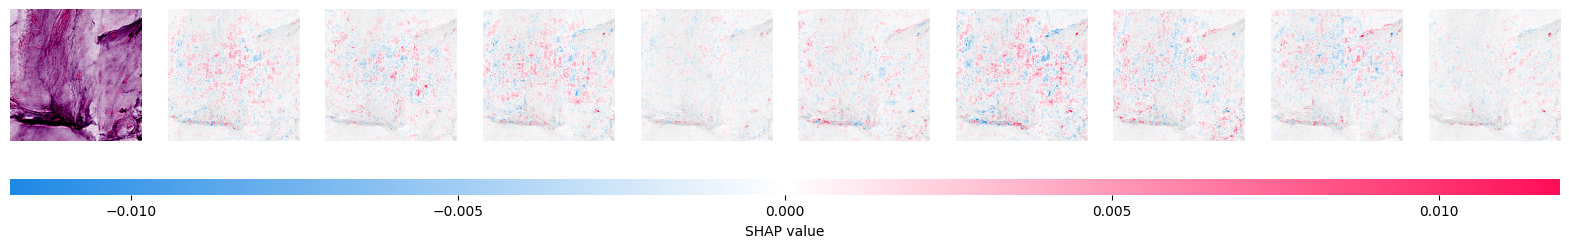

In [31]:

def shap_ex(model, img, test_loader):
    torch.cuda.empty_cache()
    device = next(model.parameters()).device
    batch = next(iter(test_loader))
    images, _ = batch
    images = images.to(device)
    
    background = images
    test_images = img.unsqueeze(0).to(device)
    
    e = shap.DeepExplainer(model, background)
    shap_values = e.shap_values(test_images,check_additivity=False)
    
    shap_numpy = [np.transpose(shap, (1, 2, 3, 0)) for shap in shap_values]
    test_numpy = np.transpose(test_images.cpu().numpy(), (0, 2, 3, 1))
    
    shap.image_plot(shap_numpy, test_numpy)
    del e, shap_values, background, test_images
    torch.cuda.empty_cache()
# 调用 shap_ex 函数
img = next(iter(test_loader))[0][2]
shap_ex(model, img, test_loader)

['mucus']


PartitionExplainer explainer: 2it [01:01, 61.66s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


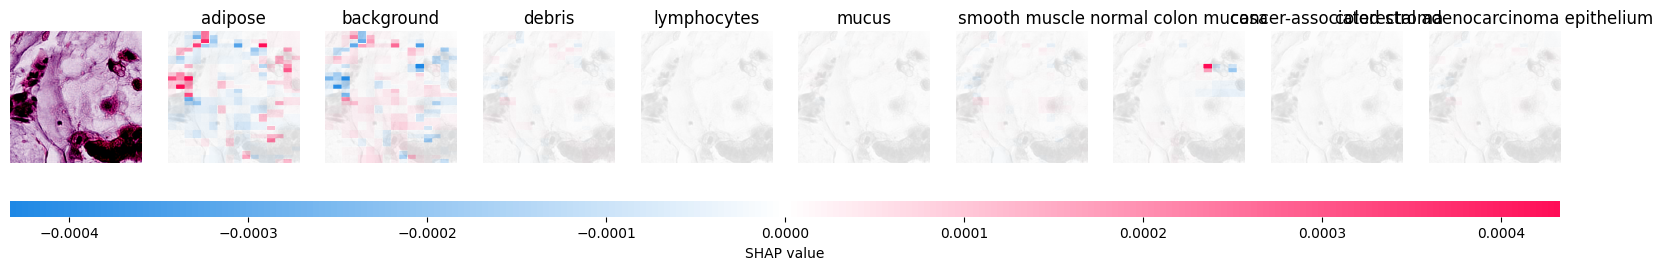

In [30]:
import shap
import torch
import numpy as np

# 假设 model 是您训练好的模型
# 假设 test_loader 是您的测试数据加载器

# 设置设备和模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 定义模型预测函数
def f(x):
    x = torch.from_numpy(x).permute(0, 3, 1, 2).float()
    x = x.to(device)

    # 归一化（根据您的实际情况调整）
    mean = torch.tensor([0.5, 0.5, 0.5]).to(device)
    std = torch.tensor([0.5, 0.5, 0.5]).to(device)
    x = (x - mean[:, None, None]) / std[:, None, None]

    with torch.no_grad():
        outputs = model(x)
        outputs = torch.nn.functional.softmax(outputs, dim=1)
        outputs = outputs.cpu().numpy()
    return outputs

# 获取一批测试图像
batch = next(iter(test_loader))
images, labels = batch
X = images.permute(0, 2, 3, 1).cpu().numpy()

# 创建 masker
masker = shap.maskers.Image("inpaint_telea", X[0].shape)
# masker = shap.maskers.Image("blur(8, 8)", X[0].shape)

from medmnist.dataset import INFO

# 提取 PathMNIST 类别名称
class_names = [label for _, label in INFO["pathmnist"]["label"].items()]

# 创建解释器
explainer = shap.Explainer(f, masker, output_names=class_names)
# 假设 labels 是张量，包含类别索引
# 计算 SHAP 值
shap_values = explainer(X[4:5], max_evals=5000, batch_size=50)
print([class_names[label.item()] for label in labels[4:5]])

# 可视化 SHAP 值
shap.image_plot(shap_values)

In [24]:
class_names

['adipose',
 'background',
 'debris',
 'lymphocytes',
 'mucus',
 'smooth muscle',
 'normal colon mucosa',
 'cancer-associated stroma',
 'colorectal adenocarcinoma epithelium']